
Event counts after filtering (p95 mode):
     La Niña: 137 unique dates
     El Niño: 98 unique dates
        nIOD: 39 unique dates
        pIOD: 22 unique dates

Fallback counts:
ENSO fallback used: 7602 rows
IOD  fallback used: 3234 rows

Building composites for La Niña minus El Niño

Building composites for nIOD minus pIOD


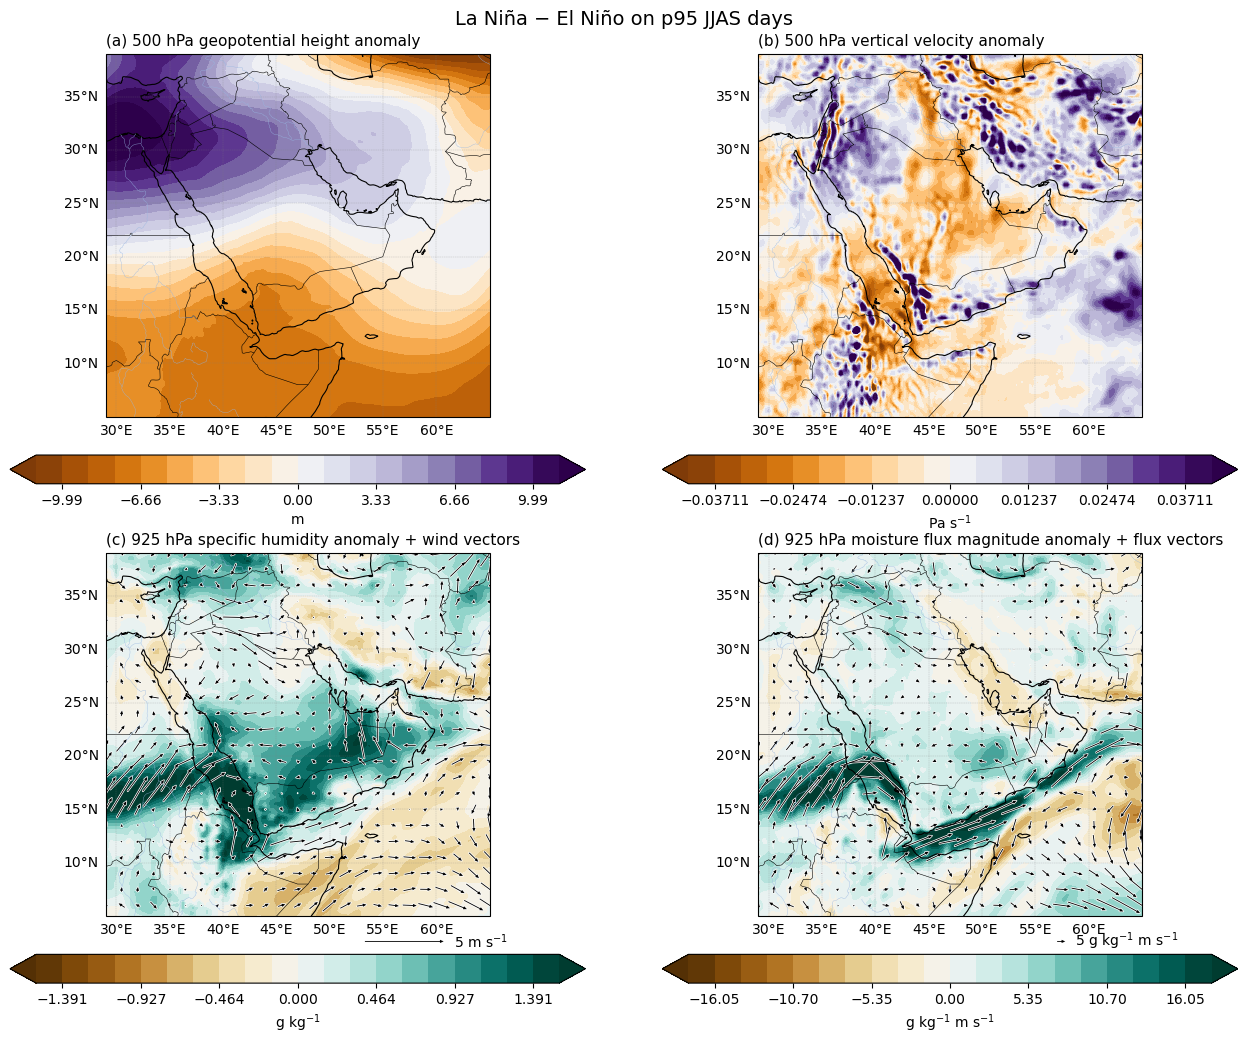

Saved ../figures/mechanism_composites/lanina_minus_elnino_p95_four_panel.png


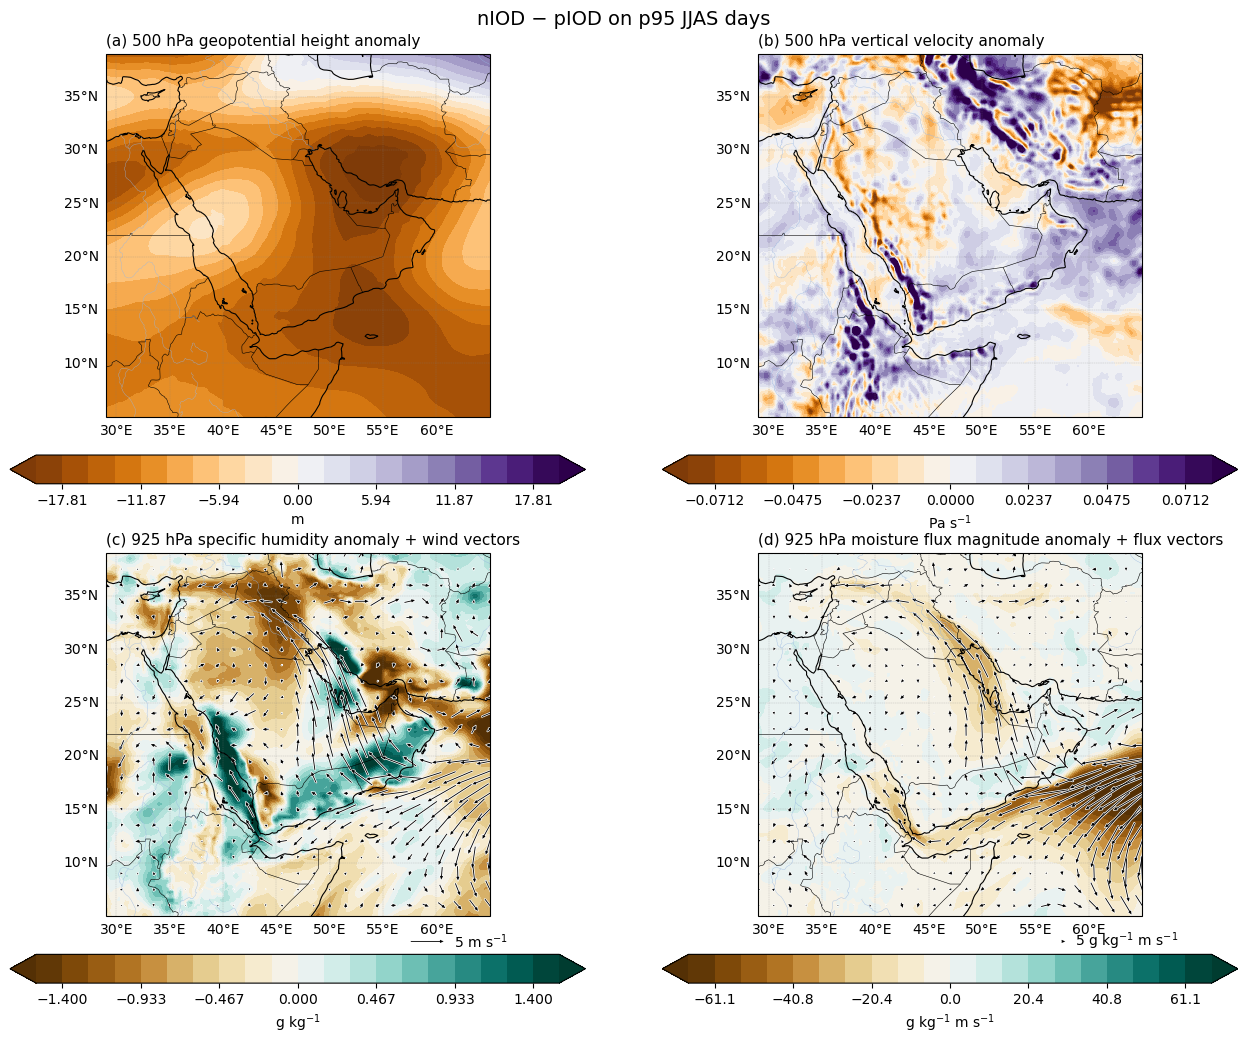

Saved ../figures/mechanism_composites/niod_minus_piod_p95_four_panel.png
Saved ../figures/mechanism_composites/mechanism_composites_p95_manuscript.pdf


In [6]:
#!/usr/bin/env python3

from pathlib import Path
import os
import contextlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# Paths
# ============================================================
ANOM_ROOT = Path("../data/era5_anomalies")
FIG_DIR = Path("../figures/mechanism_composites")
FIG_DIR.mkdir(parents=True, exist_ok=True)

EVENT_CSV = Path("../data/wbt_sst_city_runs/city_daily_wbt_JJAS_with_lagged_phases.csv")

# ============================================================
# User settings
# ============================================================
CITY = None
# Examples:
# CITY = "dubai"
# CITY = ["dubai", "doha"]
# CITY = None   -> all cities pooled

MONTHS = [6, 7, 8, 9]   # JJAS
WBT_COL = "wbt_daily_peak"
DATE_COL = "time"
CITY_COL = "city"

# ------------------------------------------------------------
# plotting mode:
# "p95" = only p95 WBT days
# "all" = all JJAS days in each phase
# ------------------------------------------------------------
DAY_MODE = "p95"   # "p95" or "all"

PHASE_PAIRS = [
    ("La Niña", "El Niño", "lanina_minus_elnino"),
    ("nIOD", "pIOD", "niod_minus_piod"),
]

# map extent
LON_MIN, LON_MAX = 29, 65
LAT_MIN, LAT_MAX = 5, 39

# vector thinning
QUIVER_STRIDE = 6

# percentile used for symmetric robust color scaling
ROBUST_PCT = 98

# geopotential -> geopotential height conversion
G = 9.81

# unit conversions
KGKG_TO_GKG = 1000.0

# xarray open settings
OPEN_MFDATASET_KW = dict(
    combine="by_coords",
    parallel=False,
    coords="minimal",
    compat="override",
)

# ============================================================
# Figure style (ERL-friendly PDF)
# ============================================================
ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "path.simplify": False,
    "savefig.transparent": False,
}

PANEL_LABELS_4 = ["(a)", "(b)", "(c)", "(d)"]
PANEL_LABELS_8 = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

# ============================================================
# Helpers
# ============================================================
@contextlib.contextmanager
def suppress_stderr():
    """
    Suppress low-level stderr output, useful for noisy HDF5 diagnostic messages.
    """
    old_stderr_fd = os.dup(2)
    devnull = os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 2)
        yield
    finally:
        os.dup2(old_stderr_fd, 2)
        os.close(devnull)
        os.close(old_stderr_fd)


def _normalize_phase_text(s: pd.Series) -> pd.Series:
    """
    Clean common text inconsistencies in phase labels.
    """
    out = s.astype(str).str.strip()
    out = out.replace({"nan": np.nan, "None": np.nan, "": np.nan})

    replacements = {
        "La Nina": "La Niña",
        "El Nino": "El Niño",
        "la nina": "La Niña",
        "el nino": "El Niño",
        "la niña": "La Niña",
        "el niño": "El Niño",
        "positive IOD": "pIOD",
        "negative IOD": "nIOD",
        "Positive IOD": "pIOD",
        "Negative IOD": "nIOD",
    }
    out = out.replace(replacements)
    return out


def get_lat_lon_names(da: xr.DataArray):
    lat_name = "latitude" if "latitude" in da.coords else "lat"
    lon_name = "longitude" if "longitude" in da.coords else "lon"
    return lat_name, lon_name


def find_time_coord(obj):
    """
    Return the time coordinate name for a DataArray/Dataset.
    """
    for cand in ["time", "date", "valid_time"]:
        if cand in obj.coords:
            return cand
        if cand in obj.dims:
            return cand
    raise KeyError(
        f"Could not find a time coordinate/dimension. Available coords={list(obj.coords)}, dims={list(obj.dims)}"
    )


def centered_levels_from_arrays(arrays, nlev=21, pct=ROBUST_PCT):
    vals = []
    for a in arrays:
        x = np.asarray(a).ravel()
        x = x[np.isfinite(x)]
        if x.size > 0:
            vals.append(x)

    if not vals:
        return np.linspace(-1, 1, nlev)

    vals = np.concatenate(vals)
    vmax = np.nanpercentile(np.abs(vals), pct)

    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(vals))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    return np.linspace(-vmax, vmax, nlev)


def style_map(ax, manuscript=False, show_grid_labels=True):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.6 if manuscript else 0.8)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.35 if manuscript else 0.4)
    ax.add_feature(cfeature.LAKES.with_scale("50m"), linewidth=0.25, facecolor="none")
    ax.add_feature(cfeature.RIVERS.with_scale("50m"), linewidth=0.25)

    gl = ax.gridlines(
        draw_labels=show_grid_labels,
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )

    if show_grid_labels:
        gl.top_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(30, 66, 5))
        gl.ylocator = mticker.FixedLocator(np.arange(5, 40, 5))

        if manuscript:
            gl.xlabel_style = {"size": 7}
            gl.ylabel_style = {"size": 7}


def add_panel_label(ax, label, manuscript=False):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9 if manuscript else 11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.2),
        zorder=20,
    )


def open_all_monthly_anoms(var_name: str) -> xr.DataArray:
    files = sorted((ANOM_ROOT / var_name).glob("*.nc"))
    if not files:
        raise FileNotFoundError(f"No anomaly files found for {var_name} in {ANOM_ROOT / var_name}")

    ds = xr.open_mfdataset(files, engine="h5netcdf")

    if len(ds.data_vars) != 1:
        raise ValueError(f"Expected 1 variable in {var_name}, got {list(ds.data_vars)}")

    da_name = list(ds.data_vars)[0]
    da = ds[da_name]

    time_name = find_time_coord(da)
    if time_name != "time":
        da = da.rename({time_name: "time"})

    da = da.sortby("time")
    return da


def classify_enso(val):
    if pd.isna(val):
        return np.nan
    if val >= 1:
        return "El Niño"
    elif val <= -1:
        return "La Niña"
    else:
        return "Neutral"


def classify_iod(val):
    if pd.isna(val):
        return np.nan
    if val >= 1:
        return "pIOD"
    elif val <= -1:
        return "nIOD"
    else:
        return "Neutral"


def load_event_dates(day_mode=DAY_MODE):
    df = pd.read_csv(EVENT_CSV)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])

    if CITY is not None:
        if isinstance(CITY, str):
            cities = [CITY]
        else:
            cities = list(CITY)
        df = df[df[CITY_COL].isin(cities)].copy()

    df["month_start"] = df[DATE_COL].dt.to_period("M").dt.to_timestamp()

    if day_mode.lower() == "p95":
        df["thresh"] = df.groupby(CITY_COL)[WBT_COL].transform(lambda x: x.quantile(0.95))
        df = df[df[WBT_COL] >= df["thresh"]].copy()
        mode_label = "p95"
    elif day_mode.lower() == "all":
        mode_label = "all"
    else:
        raise ValueError("DAY_MODE must be 'p95' or 'all'")

    monthly = df[df["lag"] == 0].copy()
    if monthly.empty:
        raise ValueError("No lag==0 rows found in event CSV")

    monthly = (
        monthly[["month_start", "RONI_lag", "DMI_lag"]]
        .drop_duplicates(subset=["month_start"])
        .sort_values("month_start")
        .reset_index(drop=True)
    )

    monthly["enso_phase_now"] = monthly["RONI_lag"].apply(classify_enso)
    monthly["iod_phase_now"]  = monthly["DMI_lag"].apply(classify_iod)

    enso_shifted = monthly[["month_start", "enso_phase_now"]].copy()
    enso_shifted["month_start"] = enso_shifted["month_start"] + pd.DateOffset(months=2)
    enso_shifted = enso_shifted.rename(columns={"enso_phase_now": "enso_phase_shifted"})

    iod_shifted = monthly[["month_start", "iod_phase_now"]].copy()
    iod_shifted["month_start"] = iod_shifted["month_start"] + pd.DateOffset(months=1)
    iod_shifted = iod_shifted.rename(columns={"iod_phase_now": "iod_phase_shifted"})

    df = df.merge(
        monthly[["month_start", "enso_phase_now", "iod_phase_now"]],
        on="month_start",
        how="left",
    )
    df = df.merge(enso_shifted, on="month_start", how="left")
    df = df.merge(iod_shifted, on="month_start", how="left")

    df["month_num"] = df[DATE_COL].dt.month

    df["enso_phase_final"] = df["enso_phase_shifted"]
    enso_fallback = (
        df["enso_phase_final"].isna()
        & df["month_num"].isin([6, 7])
    )
    df.loc[enso_fallback, "enso_phase_final"] = df.loc[enso_fallback, "enso_phase_now"]

    df["iod_phase_final"] = df["iod_phase_shifted"]
    iod_fallback = (
        df["iod_phase_final"].isna()
        & df["month_num"].isin([6])
    )
    df.loc[iod_fallback, "iod_phase_final"] = df.loc[iod_fallback, "iod_phase_now"]

    df = df[df["month_num"].isin(MONTHS)].copy()

    phase_dates = {}

    for phase in ["La Niña", "El Niño"]:
        sub = df[df["enso_phase_final"] == phase].copy()
        phase_dates[phase] = pd.DatetimeIndex(sorted(sub[DATE_COL].dt.normalize().unique()))

    for phase in ["nIOD", "pIOD"]:
        sub = df[df["iod_phase_final"] == phase].copy()
        phase_dates[phase] = pd.DatetimeIndex(sorted(sub[DATE_COL].dt.normalize().unique()))

    print(f"\nEvent counts after filtering ({mode_label} mode):")
    for k in ["La Niña", "El Niño", "nIOD", "pIOD"]:
        print(f"{k:>12s}: {len(phase_dates[k])} unique dates")

    print("\nFallback counts:")
    print(f"ENSO fallback used: {enso_fallback.sum()} rows")
    print(f"IOD  fallback used: {iod_fallback.sum()} rows")

    return phase_dates, mode_label


def composite_on_dates(da: xr.DataArray, dates: pd.DatetimeIndex) -> xr.DataArray:
    if len(dates) == 0:
        raise ValueError("No dates provided for composite")

    da = da.assign_coords(date=("time", pd.to_datetime(da["time"].values).normalize()))
    target_dates = pd.to_datetime(dates).normalize()

    mask = np.isin(da["date"].values, target_dates.values)
    da_sel = da.isel(time=mask)

    if da_sel.sizes.get("time", 0) == 0:
        raise ValueError("No matching anomaly times found for requested dates")

    return da_sel.mean("time", skipna=True)


def make_difference_composites(phase_dates, mode_label):
    z = open_all_monthly_anoms("geopotential") / G
    z = z.rename("geopotential_height_anom")

    omega = open_all_monthly_anoms("vertical_velocity")
    omega = omega.rename("vertical_velocity_anom")

    q = open_all_monthly_anoms("specific_humidity") * KGKG_TO_GKG
    q = q.rename("specific_humidity_anom_gkg")

    u = open_all_monthly_anoms("u_component_of_wind")
    u = u.rename("u_wind_anom")

    v = open_all_monthly_anoms("v_component_of_wind")
    v = v.rename("v_wind_anom")

    mfmag = open_all_monthly_anoms("moisture_flux_mag_925") * KGKG_TO_GKG
    mfmag = mfmag.rename("moisture_flux_mag_925_anom_gkg_ms")

    mfu = open_all_monthly_anoms("moisture_flux_u_925") * KGKG_TO_GKG
    mfu = mfu.rename("moisture_flux_u_925_anom_gkg_ms")

    mfv = open_all_monthly_anoms("moisture_flux_v_925") * KGKG_TO_GKG
    mfv = mfv.rename("moisture_flux_v_925_anom_gkg_ms")

    out = {}

    for pos_phase, neg_phase, base_tag in PHASE_PAIRS:
        if pos_phase not in phase_dates:
            raise ValueError(f"Phase {pos_phase} not found in event dates")
        if neg_phase not in phase_dates:
            raise ValueError(f"Phase {neg_phase} not found in event dates")

        print(f"\nBuilding composites for {pos_phase} minus {neg_phase}")

        z_pos = composite_on_dates(z, phase_dates[pos_phase])
        z_neg = composite_on_dates(z, phase_dates[neg_phase])

        omega_pos = composite_on_dates(omega, phase_dates[pos_phase])
        omega_neg = composite_on_dates(omega, phase_dates[neg_phase])

        q_pos = composite_on_dates(q, phase_dates[pos_phase])
        q_neg = composite_on_dates(q, phase_dates[neg_phase])

        u_pos = composite_on_dates(u, phase_dates[pos_phase])
        u_neg = composite_on_dates(u, phase_dates[neg_phase])

        v_pos = composite_on_dates(v, phase_dates[pos_phase])
        v_neg = composite_on_dates(v, phase_dates[neg_phase])

        mfmag_pos = composite_on_dates(mfmag, phase_dates[pos_phase])
        mfmag_neg = composite_on_dates(mfmag, phase_dates[neg_phase])

        mfu_pos = composite_on_dates(mfu, phase_dates[pos_phase])
        mfu_neg = composite_on_dates(mfu, phase_dates[neg_phase])

        mfv_pos = composite_on_dates(mfv, phase_dates[pos_phase])
        mfv_neg = composite_on_dates(mfv, phase_dates[neg_phase])

        tag = f"{base_tag}_{mode_label}"

        out[tag] = {
            "title": f"{pos_phase} − {neg_phase} on {mode_label} JJAS days",
            "z": z_pos - z_neg,
            "omega": omega_pos - omega_neg,
            "q": q_pos - q_neg,
            "u": u_pos - u_neg,
            "v": v_pos - v_neg,
            "mfmag": mfmag_pos - mfmag_neg,
            "mfu": mfu_pos - mfu_neg,
            "mfv": mfv_pos - mfv_neg,
            "n_pos": len(phase_dates[pos_phase]),
            "n_neg": len(phase_dates[neg_phase]),
            "tag": tag,
        }

    return out


def add_quiver(ax, u, v, stride=QUIVER_STRIDE, scale=None):
    lat_name, lon_name = get_lat_lon_names(u)

    u2 = u.isel({lat_name: slice(None, None, stride), lon_name: slice(None, None, stride)})
    v2 = v.isel({lat_name: slice(None, None, stride), lon_name: slice(None, None, stride)})

    lon2d, lat2d = np.meshgrid(u2[lon_name].values, u2[lat_name].values)

    qv = ax.quiver(
        lon2d, lat2d,
        u2.values, v2.values,
        transform=ccrs.PlateCarree(),
        scale=scale,
        width=0.0022,
        headwidth=3.7,
        headlength=4.2,
        minlength=0.05,
        pivot="middle",
        color="black",
        path_effects=[
            pe.Stroke(linewidth=1.05, foreground="white"),
            pe.Normal()
        ],
    )
    return qv


def get_shared_levels(comps):
    z_levels = centered_levels_from_arrays([comp["z"].values for comp in comps.values()], nlev=21)
    omega_levels = centered_levels_from_arrays([comp["omega"].values for comp in comps.values()], nlev=21)
    q_levels = centered_levels_from_arrays([comp["q"].values for comp in comps.values()], nlev=21)
    mfmag_levels = centered_levels_from_arrays([comp["mfmag"].values for comp in comps.values()], nlev=21)
    return z_levels, omega_levels, q_levels, mfmag_levels


def plot_four_panel(comp, outpath):
    """
    Original layout retained for talk/poster use.
    Only change: move quiver keys slightly upward to avoid clipping.
    """
    proj = ccrs.PlateCarree()

    z = comp["z"]
    omega = comp["omega"]
    q = comp["q"]
    u = comp["u"]
    v = comp["v"]
    mfmag = comp["mfmag"]
    mfu = comp["mfu"]
    mfv = comp["mfv"]

    lat_name, lon_name = get_lat_lon_names(z)

    z_levels = centered_levels_from_arrays([z.values], nlev=21)
    omega_levels = centered_levels_from_arrays([omega.values], nlev=21)
    q_levels = centered_levels_from_arrays([q.values], nlev=21)
    mfmag_levels = centered_levels_from_arrays([mfmag.values], nlev=21)

    fig, axes = plt.subplots(
        2, 2,
        figsize=(13, 10),
        subplot_kw={"projection": proj},
        constrained_layout=True,
    )
    axes = axes.ravel()

    ax = axes[0]
    style_map(ax, manuscript=False)
    cf1 = ax.contourf(
        z[lon_name], z[lat_name], z,
        levels=z_levels,
        cmap="PuOr",
        extend="both",
        transform=proj,
    )
    ax.set_title("(a) 500 hPa geopotential height anomaly", loc="left", fontsize=11)
    cbar1 = fig.colorbar(cf1, ax=ax, orientation="horizontal", pad=0.04, shrink=0.9)
    cbar1.set_label("m")

    ax = axes[1]
    style_map(ax, manuscript=False)
    cf2 = ax.contourf(
        omega[lon_name], omega[lat_name], omega,
        levels=omega_levels,
        cmap="PuOr",
        extend="both",
        transform=proj,
    )
    ax.set_title("(b) 500 hPa vertical velocity anomaly", loc="left", fontsize=11)
    cbar2 = fig.colorbar(cf2, ax=ax, orientation="horizontal", pad=0.04, shrink=0.9)
    cbar2.set_label("Pa s$^{-1}$")

    ax = axes[2]
    style_map(ax, manuscript=False)
    cf3 = ax.contourf(
        q[lon_name], q[lat_name], q,
        levels=q_levels,
        cmap="BrBG",
        extend="both",
        transform=proj,
    )
    qv1 = add_quiver(ax, u, v, stride=QUIVER_STRIDE, scale=None)
    ax.quiverkey(
        qv1, 0.88, -0.07, 5, "5 m s$^{-1}$",
        labelpos="E", coordinates="axes"
    )
    ax.set_title("(c) 925 hPa specific humidity anomaly + wind vectors", loc="left", fontsize=11)
    cbar3 = fig.colorbar(cf3, ax=ax, orientation="horizontal", pad=0.04, shrink=0.9)
    cbar3.set_label("g kg$^{-1}$")

    ax = axes[3]
    style_map(ax, manuscript=False)
    cf4 = ax.contourf(
        mfmag[lon_name], mfmag[lat_name], mfmag,
        levels=mfmag_levels,
        cmap="BrBG",
        extend="both",
        transform=proj,
    )
    qv2 = add_quiver(ax, mfu, mfv, stride=QUIVER_STRIDE, scale=None)
    ax.quiverkey(
        qv2, 0.80, -0.07, 5, "5 g kg$^{-1}$ m s$^{-1}$",
        labelpos="E", coordinates="axes"
    )
    ax.set_title("(d) 925 hPa moisture flux magnitude anomaly + flux vectors", loc="left", fontsize=11)
    cbar4 = fig.colorbar(cf4, ax=ax, orientation="horizontal", pad=0.04, shrink=0.9)
    cbar4.set_label("g kg$^{-1}$ m s$^{-1}$")

    fig.suptitle(
        f"{comp['title']}",
        fontsize=14,
        y=1.02,
    )

    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_manuscript_8panel(comps, outpath):
    """
    Manuscript figure:
      columns = phase contrast (ENSO left, IOD right)
      rows    = variable
    No titles/subtitles; panel labels only.
    Lat/lon labels only on the first panel to avoid clipping quiver panels.
    """
    proj = ccrs.PlateCarree()

    enso_key = [k for k in comps if k.startswith("lanina_minus_elnino_")][0]
    iod_key  = [k for k in comps if k.startswith("niod_minus_piod_")][0]

    enso = comps[enso_key]
    iod  = comps[iod_key]

    z_levels, omega_levels, q_levels, mfmag_levels = get_shared_levels(comps)

    lat_name, lon_name = get_lat_lon_names(enso["z"])

    with mpl.rc_context(ERL_RC):
        fig, axes = plt.subplots(
            4, 2,
            figsize=(7.1, 10.6),
            subplot_kw={"projection": proj},
            constrained_layout=False,
        )

        # Pull columns/rows a bit closer together
        fig.subplots_adjust(
            left=0.10,
            right=0.98,
            top=0.94,
            bottom=0.05,
            wspace=0.06,   
            hspace=0.16
        )

        # Column headers
        fig.text(
            0.29, 0.975,
            "ENSO\nLa Niña − El Niño",
            ha="center", va="top",
            fontsize=10, fontweight="bold"
        )
        
        fig.text(
            0.74, 0.975,
            "IOD\nnIOD − pIOD",
            ha="center", va="top",
            fontsize=10, fontweight="bold"
        )
        row_labels = [
            "500 hPa $Z_g$",
            "500 hPa $\Omega$",
            "925 hPa $q$",
            "925 hPa $qu\cdot v$"
        ]
        
        for r, label in enumerate(row_labels):
            pos_left  = axes[r,0].get_position()
            pos_right = axes[r,1].get_position()
        
            xmid = (pos_left.x1 + pos_right.x0) / 2
            ymid = (pos_left.y0 + pos_left.y1) / 2
        
            fig.text(
                xmid,
                ymid,
                label,
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold"
            )
            
        fields = [
            ("z", "PuOr", z_levels, None, None),
            ("omega", "PuOr", omega_levels, None, None),
            ("q", "BrBG", q_levels, "u", "v"),
            ("mfmag", "BrBG", mfmag_levels, "mfu", "mfv"),
        ]

        col_comps = [enso, iod]
        panel_idx = 0
        mappables = {}

        for r, (field_name, cmap, levels, u_name, v_name) in enumerate(fields):
            for c, comp in enumerate(col_comps):
                ax = axes[r, c]

                # Only first panel gets lat/lon labels
                show_grid_labels = (r == 0 and c == 0)
                style_map(ax, manuscript=True, show_grid_labels=show_grid_labels)

                field = comp[field_name]
                cf = ax.contourf(
                    field[lon_name], field[lat_name], field,
                    levels=levels,
                    cmap=cmap,
                    extend="both",
                    transform=proj,
                )

                if c == 0:
                    mappables[field_name] = cf

                if u_name is not None and v_name is not None:
                    qv = add_quiver(
                        ax,
                        comp[u_name],
                        comp[v_name],
                        stride=QUIVER_STRIDE,
                        scale=None
                    )

                    if field_name == "q":
                        ax.quiverkey(
                            qv, 0.50, -0.045, 5, "5 m s$^{-1}$",
                            labelpos="E", coordinates="axes",
                            fontproperties={"size": 7}
                        )
                    elif field_name == "mfmag":
                        ax.quiverkey(
                            qv, 0.50, -0.045, 15, "15 g kg$^{-1}$ m s$^{-1}$",
                            labelpos="E", coordinates="axes",
                            fontproperties={"size": 7}
                        )

                add_panel_label(ax, PANEL_LABELS_8[panel_idx], manuscript=True)
                panel_idx += 1

        # Row-wise colorbars spanning both columns
        cbar1 = fig.colorbar(
            mappables["z"], ax=axes[0, :], orientation="horizontal",
            pad=0.08, shrink=0.90
        )
        cbar1.set_label("m")

        cbar2 = fig.colorbar(
            mappables["omega"], ax=axes[1, :], orientation="horizontal",
            pad=0.08, shrink=0.90
        )
        cbar2.set_label("Pa s$^{-1}$")

        cbar3 = fig.colorbar(
            mappables["q"], ax=axes[2, :], orientation="horizontal",
            pad=0.08, shrink=0.90
        )
        cbar3.set_label("g kg$^{-1}$")

        cbar4 = fig.colorbar(
            mappables["mfmag"], ax=axes[3, :], orientation="horizontal",
            pad=0.08, shrink=0.90
        )
        cbar4.set_label("g kg$^{-1}$ m s$^{-1}$")

        for cbar in [cbar1, cbar2, cbar3, cbar4]:
            cbar.ax.tick_params(labelsize=7)

        fig.savefig(outpath, dpi=300, bbox_inches="tight", pad_inches=0.02)
        plt.close(fig)


# ============================================================
# Main
# ============================================================
def main():
    phase_dates, mode_label = load_event_dates(day_mode=DAY_MODE)
    comps = make_difference_composites(phase_dates, mode_label)

    # Keep original PNG outputs, only with quiver keys moved slightly upward
    for tag, comp in comps.items():
        outpath = FIG_DIR / f"{tag}_four_panel.png"
        plot_four_panel(comp, outpath)
        print(f"Saved {outpath}")

    # New combined manuscript PDF
    pdf_out = FIG_DIR / f"mechanism_composites_{mode_label}_manuscript.pdf"
    plot_manuscript_8panel(comps, pdf_out)
    print(f"Saved {pdf_out}")


if __name__ == "__main__":
    main()